## **Word Embeddings**

In [1]:
!pip install scikit-learn pandas numpy


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

# Load Reddit
reddit_corpus = pd.read_csv("../data/Reddit/reddit_clean.csv")
print(reddit_corpus.tail())

# Load Rappler
rappler_corpus = pd.read_csv("../data/News/rappler_clean.csv")
print(rappler_corpus.tail())


                                              post_title  \
12725  Philippines, Japan deepen ties with $1.5 billi...   
12726  Philippines, Japan deepen ties with $1.5 billi...   
12727  Philippines, Japan deepen ties with $1.5 billi...   
12728  Philippines, Japan deepen ties with $1.5 billi...   
12729  Philippines, Japan deepen ties with $1.5 billi...   

                                                post_url  \
12725  https://reddit.com/r/Philippines/comments/1cio...   
12726  https://reddit.com/r/Philippines/comments/1cio...   
12727  https://reddit.com/r/Philippines/comments/1cio...   
12728  https://reddit.com/r/Philippines/comments/1cio...   
12729  https://reddit.com/r/Philippines/comments/1cio...   

                                                 comment post_body  \
12725                       that’s why fuck the dutertes       NaN   
12726                                  fr? that's scary.       NaN   
12727                  this partnership is very daijoubu       NaN  

In [3]:
reddit_texts = reddit_corpus["post_full"].astype(str).tolist()
rappler_texts = rappler_corpus["text"].astype(str).tolist()


In [4]:
# Stopwrods

import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")
english_stop = stopwords.words("english")

filipino_stopwords = [
    "sa","ang","ng","mga","si","ni","kay","kina",
    "ito","iyan","iyon","doon","diyan","dito",
    "ko","mo","nya","niya","natin","namin","nyo","ninyo",
    "sila","kami","tayo","kayo",
    "ay","may","wala","meron","naman","rin","din",
    "pa","ba","po","ho","eh","yung","yup","nope",
    "kung","kapag","pero","kasi","para","habang","bago",
    "nga","lang","daw","raw","yata","pala","talaga",
    "siguro","naka","ni","siya",
    
    # noise words
    "haha","hahaha","hehe","lol","omg","hmmmm","hmmmmmm",
    "tsk","hay","amp","grabe",
    
    # more noise as the code is ran
    "lalala", "brgy", "sen", "ph", "phl", "gov",
    "committee", "chairmanships"
]

combined_stopwords = list(set(english_stop + filipino_stopwords))



[nltk_data] Downloading package stopwords to /Users/uwie/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


---
**Reddit BoW**

In [32]:
from sklearn.feature_extraction.text import CountVectorizer

# Use only the combined post text (title + body)
texts_reddit = reddit_corpus["post_full"].astype(str)

vectorizer = CountVectorizer(
    stop_words=combined_stopwords,
    max_df=0.95,
    min_df=2,
    token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z]+\b'   # remove numbers, symbols, 1-letter tokens
)

reddit_bow = vectorizer.fit_transform(texts_reddit)
reddit_bow.shape


(12730, 1790)

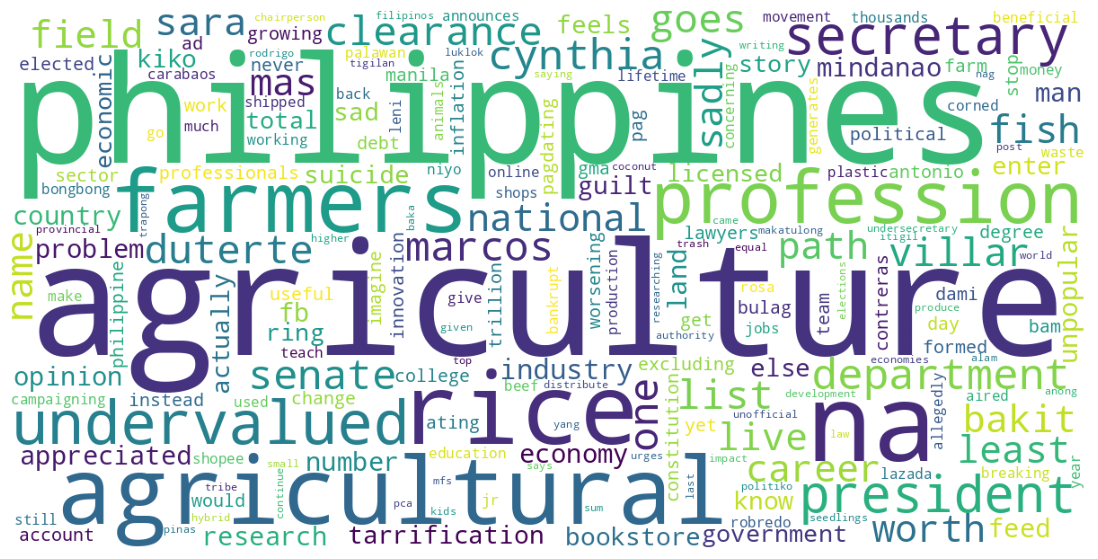

In [33]:
from wordcloud import WordCloud
import numpy as np
import matplotlib.pyplot as plt

# Get vocabulary + term frequencies
vocab = vectorizer.get_feature_names_out()
word_freq = np.array(reddit_bow.sum(axis=0)).flatten()

freq_dict = dict(zip(vocab, word_freq))

# Generate the cleaned, BoW-based wordcloud
plt.figure(figsize=(15, 7))
wc = WordCloud(
    width=1200,
    height=600,
    background_color="white"
)
plt.imshow(wc.generate_from_frequencies(freq_dict))
plt.axis("off")
plt.show()


---
**Rappler BoW**

In [43]:
from sklearn.feature_extraction.text import CountVectorizer

# Use only the combined post text (title + body)
texts_reddit = rappler_corpus["cleaned_text"].astype(str)

vectorizer = CountVectorizer(
    stop_words=combined_stopwords,
    max_df=0.95,
    min_df=2,
    token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z]+\b'   # remove numbers, symbols, 1-letter tokens
)

rappler_bow = vectorizer.fit_transform(texts_reddit)
rappler_bow.shape


(121, 3878)

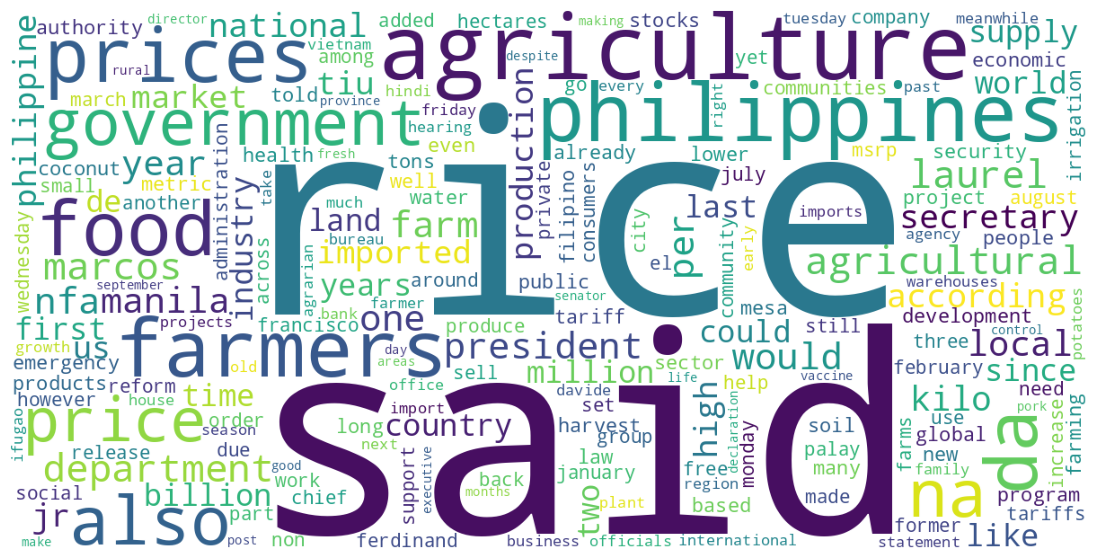

In [44]:
from wordcloud import WordCloud
import numpy as np
import matplotlib.pyplot as plt

# Get vocabulary + term frequencies
vocab = vectorizer.get_feature_names_out()
word_freq = np.array(rappler_bow.sum(axis=0)).flatten()

freq_dict = dict(zip(vocab, word_freq))

# Generate the cleaned, BoW-based wordcloud
plt.figure(figsize=(15, 7))
wc = WordCloud(
    width=1200,
    height=600,
    background_color="white"
)
plt.imshow(wc.generate_from_frequencies(freq_dict))
plt.axis("off")
plt.show()


---
**LDA, Topic Modelling for Reddit**

In [9]:
from sklearn.decomposition import LatentDirichletAllocation

reddit_lda_model = LatentDirichletAllocation(
    n_components=5,
    random_state=42,
    learning_method='batch'
)
reddit_lda_model.fit(reddit_bow)


,n_components,5
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,10
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


In [10]:
def show_topics(model, feature_names, n_top_words=12):
    for idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_indices]
        print(f"\nTopic {idx+1}:")
        print(" | ".join(top_words))

feature_names = vectorizer.get_feature_names_out()
show_topics(reddit_lda_model, feature_names)



Topic 1:
lot | africa | integrated | cases | importing | jayson | fever | announced | million | representative | affordable | de

Topic 2:
lot | africa | done | hectare | science | businesses | living | different | integrated | importations | financial | immediately

Topic 3:
heat | laurel | growing | lot | distributed | irrigation | million | representative | parents | energy | industriya | integrated

Topic 4:
lot | affordable | october | records | landed | millions | harvest | group | di | children | among | accessible

Topic 5:
africa | operates | determined | personal | association | play | quimbo | establish | promote | mesa | result | customs


In [11]:
topic_distribution = reddit_lda_model.transform(reddit_bow)

reddit_corpus["dominant_topic"] = topic_distribution.argmax(axis=1)
reddit_corpus["topic_score"] = topic_distribution.max(axis=1)

reddit_corpus.to_csv("../data/Reddit/reddit_with_topics.csv", index=False)


---
**LDA, Topic Modelling for Rappler**

In [12]:
from sklearn.decomposition import LatentDirichletAllocation

rappler_lda_model = LatentDirichletAllocation(
    n_components=5,
    random_state=42,
    learning_method='batch'
)

rappler_lda_model.fit(rappler_bow)


,n_components,5
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,10
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


In [13]:
def show_topics(model, feature_names, n_top_words=12):
    for idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_indices]
        print(f"\nTopic {idx+1}:")
        print(" | ".join(top_words))

feature_names = vectorizer.get_feature_names_out()
show_topics(rappler_lda_model, feature_names)



Topic 1:
farmers | farm | food | one | rice | like | also | farming | years | soil | people | agricultural

Topic 2:
price | rice | prices | also | marcos | president | agriculture | year | supply | august | government | economic

Topic 3:
na | agriculture | laurel | marcos | farmers | land | agricultural | sector | reform | president | agrarian | also

Topic 4:
rice | da | prices | nfa | kilo | food | per | imported | farmers | agriculture | price | government

Topic 5:
agriculture | government | would | also | project | according | farmers | irrigation | department | production | philippine | national


In [14]:
topic_distribution = rappler_lda_model.transform(rappler_bow)

rappler_corpus["dominant_topic"] = topic_distribution.argmax(axis=1)
rappler_corpus["topic_score"] = topic_distribution.max(axis=1)

rappler_corpus.to_csv("../data/News/rappler_with_topics.csv", index=False)

---
**Checkpoint Data Viewing**

In [15]:
rappler_withTopic = pd.read_csv("../data/News/rappler_with_topics.csv")
reddit_withTopic = pd.read_csv("../data/Reddit/reddit_with_topics.csv")

rappler_withTopic.tail()

,title,link,date_published,text,cleaned_text,dominant_topic,topic_score
116,ASF spreads to 4 Aklan towns,https://www.rappler.com/philippines/visayas/as...,2023-05-18T09:10:00+08:00,"AKLAN, Philippines – A month after the first c...","aklan, philippines – a month after the first c...",1,0.992306
117,Pangasinan farmers urged to plant early as San...,https://www.rappler.com/philippines/luzon/pang...,2023-05-06T11:32:23+08:00,"DAGUPAN CITY, Philippines – With El Niño just ...","dagupan city, philippines – with el niño just ...",4,0.653853
118,[ANALYSIS] Should LBP and DBP be merged into a...,https://www.rappler.com/voices/thought-leaders...,2023-03-31T13:24:41+08:00,"On March 23, Finance Secretary Benjamin Diokno...","on march 23, finance secretary benjamin diokno...",2,0.436670
119,Sugar regulation chief Alba resigns,https://www.rappler.com/business/sugar-regulat...,2023-03-24T11:19:13+08:00,"MANILA, Philippines – Sugar Regulatory Adminis...","manila, philippines – sugar regulatory adminis...",1,0.994174
120,North Korea’s Kim orders ‘fundamental transfor...,https://www.rappler.com/world/asia-pacific/nor...,2023-02-28T11:37:49+08:00,"SEOUL, South Korea – North Korean leaderKim Jo...","seoul, south korea – north korean leaderkim jo...",4,0.658819


In [16]:

reddit_withTopic.tail()

,post_title,post_url,comment,post_body,created_utc,post_full,dominant_topic,topic_score
12725,"Philippines, Japan deepen ties with $1.5 billi...",https://reddit.com/r/Philippines/comments/1cio...,that’s why fuck the dutertes,NaN,2024-05-03 11:30:11,"philippines, japan deepen ties with $1.5 billi...",3,0.899632
12726,"Philippines, Japan deepen ties with $1.5 billi...",https://reddit.com/r/Philippines/comments/1cio...,fr? that's scary.,NaN,2024-05-03 12:32:41,"philippines, japan deepen ties with $1.5 billi...",3,0.899632
12727,"Philippines, Japan deepen ties with $1.5 billi...",https://reddit.com/r/Philippines/comments/1cio...,this partnership is very daijoubu,NaN,2024-05-03 10:33:52,"philippines, japan deepen ties with $1.5 billi...",3,0.899632
12728,"Philippines, Japan deepen ties with $1.5 billi...",https://reddit.com/r/Philippines/comments/1cio...,"yeah, there’s a huge connection between corrup...",NaN,2024-05-03 12:36:12,"philippines, japan deepen ties with $1.5 billi...",3,0.899632
12729,"Philippines, Japan deepen ties with $1.5 billi...",https://reddit.com/r/Philippines/comments/1cio...,"yup ganyan din ginagawa ng russia, kaya mas pi...",NaN,2024-05-03 16:57:35,"philippines, japan deepen ties with $1.5 billi...",3,0.899632


---

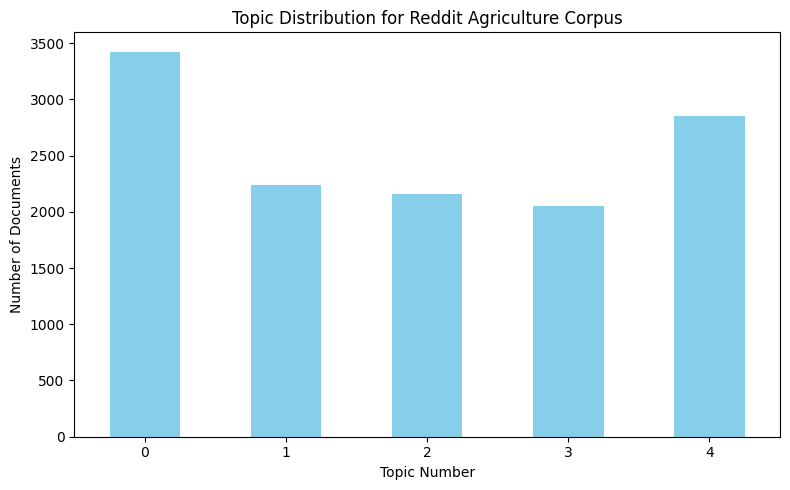

In [17]:
import matplotlib.pyplot as plt

# Count how many posts fall under each topic
reddit_topic_counts = reddit_corpus["dominant_topic"].value_counts().sort_index()

plt.figure(figsize=(8,5))
reddit_topic_counts.plot(kind="bar", color="skyblue")
plt.xlabel("Topic Number")
plt.ylabel("Number of Documents")
plt.title("Topic Distribution for Reddit Agriculture Corpus")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../IEEE/figures/reddit_topic_distribution.png", dpi=300)
plt.show()


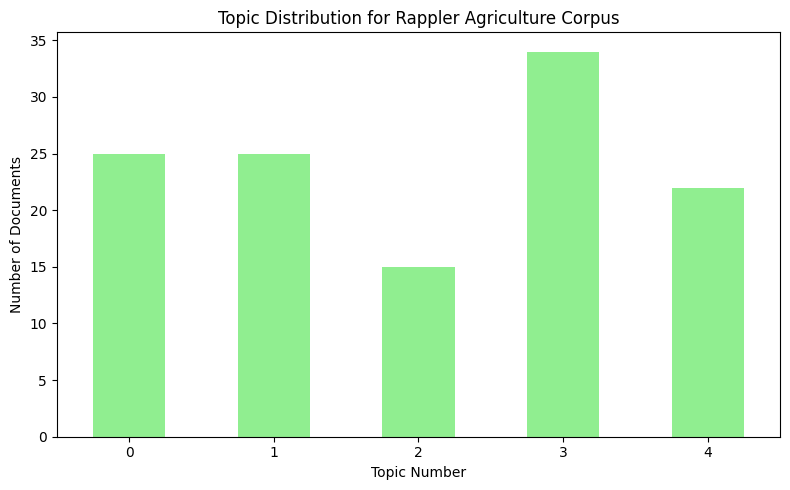

In [18]:
rappler_topic_counts = rappler_corpus["dominant_topic"].value_counts().sort_index()

plt.figure(figsize=(8,5))
rappler_topic_counts.plot(kind="bar", color="lightgreen")
plt.xlabel("Topic Number")
plt.ylabel("Number of Documents")
plt.title("Topic Distribution for Rappler Agriculture Corpus")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../IEEE/figures/rappler_topic_distribution.png", dpi=300)
plt.show()
